# 03. Affordability — 서울시 통신비 적정성 분석

**분석 목표**  
서울시 25개 구의 계층별 통신비 부담률을 산출하고, ITU UMC 기준(월소득 대비 2%) 초과 지역을 식별합니다.

**설계 원칙: 확증편향 배제**  
계층 특성(노인=취약 등)을 사전에 가정하지 않고, 데이터가 패턴을 스스로 드러내도록 합니다.


In [1]:
# 프로젝트 루트를 sys.path에 추가 (src import용)
import sys, os
from pathlib import Path

# src/ 폴더가 있는 디렉터리를 프로젝트 루트로 인식
root = Path.cwd()
while not (root / "src").exists() and root != root.parent:
    root = root.parent

if str(root) not in sys.path:
    sys.path.insert(0, str(root))

os.chdir(root)  # configs/config.yaml 등 상대경로 기준 맞추기
print(f"프로젝트 루트: {root}")

프로젝트 루트: /Users/jhhhyk/Documents/ITU Projects/itu_analize/ITU


## 1. 데이터 로드
 —  의  기준으로 읽습니다.


In [2]:
from src.data.load_affordability import load_all

data = load_all()


📂 데이터 로드
----------------------------------------
  ✓ 미디어패널  8,411명 → 서울 1,513명
  ✓ 소비지출    25개 구 (2025Q3)
  ✓ 주거형태    25개 구
  ✓ 인구        25개 구
  ✓ 기초수급자  25개 구


## 2. 전처리
 —  의  설정 자동 적용

- 
-   
- 


In [3]:
from src.preprocessing.clean_affordability import preprocess_all

cleaned = preprocess_all(data)



🔧 전처리
----------------------------------------
  ✓ 주거형태    서울 평균 월세비율 28.4%
  ✓ 인구        서울 평균 고령화율 20.2% | 60세이상 비율 27.4%
  ✓ 소비지출    서울 평균 필수지출 104.2만원/월
  ✓ 미디어패널  cost_pure 평균 3.78만원 | 중앙값 3.80만원


## 3. 데이터 탐색 (EDA)

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from pathlib import Path

# 한글 폰트 (macOS 기준 — 필요 시 경로 수정)
_font_candidates = [
    "C:/Windows/Fonts/malgun.ttf",
    "/System/Library/Fonts/AppleSDGothicNeo.ttc",
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
]
_fp = None
for _p in _font_candidates:
    if Path(_p).exists():
        _fp = fm.FontProperties(fname=_p)
        plt.rcParams["font.family"] = _fp.get_name()
        plt.rcParams["axes.unicode_minus"] = False
        break

seoul = cleaned["seoul"]
print(f"서울 샘플: {len(seoul):,}명")
print(f"순수통신비 평균: {seoul['cost_pure'].mean():.2f}만원")
print()
print("연령대 분포:")
print(seoul["age_group"].value_counts())
print()
print("소득구간 분포:")
print(seoul["income_group"].value_counts())


Matplotlib is building the font cache; this may take a moment.


서울 샘플: 1,513명
순수통신비 평균: 3.78만원

연령대 분포:
age_group
40~50대    617
60대이상     570
20~30대    266
10대이하      60
Name: count, dtype: int64

소득구간 분포:
income_group
저소득(200만미만)       585
중고소득(300~500만)    535
중저소득(200~300만)    314
고소득(500만이상)        79
Name: count, dtype: int64


/var/folders/fs/kdvlp5qj68n9rjnfvwww9bzm0000gn/T/ipykernel_34419/287215904.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_list, labels=order, patch_artist=True,
/var/folders/fs/kdvlp5qj68n9rjnfvwww9bzm0000gn/T/ipykernel_34419/287215904.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_list, labels=order, patch_artist=True,


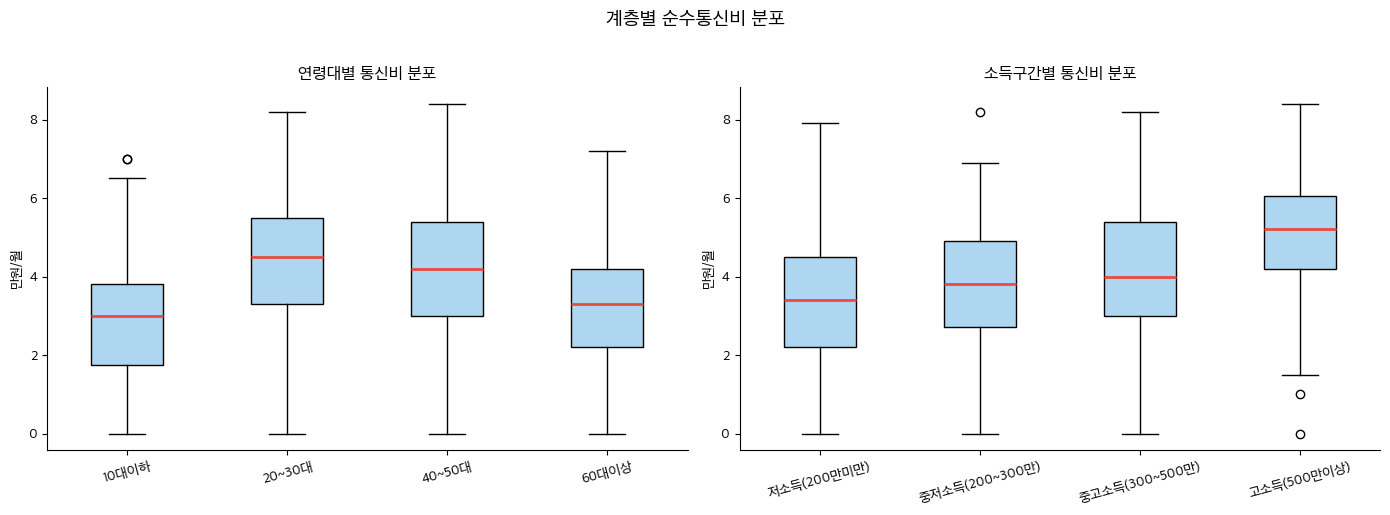

In [5]:
# 계층별 순수통신비 분포 (boxplot)
from src.preprocessing.clean_affordability import AGE_ORDER, INCOME_ORDER

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, grp, order, title in [
    (axes[0], "age_group",    AGE_ORDER,    "연령대별 통신비 분포"),
    (axes[1], "income_group", INCOME_ORDER, "소득구간별 통신비 분포"),
]:
    data_list = [seoul[seoul[grp] == g]["cost_pure"].dropna() for g in order]
    ax.boxplot(data_list, labels=order, patch_artist=True,
               boxprops=dict(facecolor="#AED6F1"),
               medianprops=dict(color="#E74C3C", linewidth=2))
    ax.set_title(title, fontproperties=_fp, fontsize=12, fontweight="bold")
    ax.set_ylabel("만원/월", fontproperties=_fp)
    ax.set_xticklabels(order, fontproperties=_fp, rotation=15)
    ax.spines[["top","right"]].set_visible(False)

plt.suptitle("계층별 순수통신비 분포", fontproperties=_fp,
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


## 4. Affordability 지표 계산



In [6]:
from src.features.affordability import run_affordability

result = run_affordability(cleaned)



📊 Affordability 지표 계산
----------------------------------------
  서울 평균 필수지출: 104.2만원/월
  계층별 부담률 (%):
        저소득(200만미만)  중저소득(200~300만)  중고소득(300~500만)  고소득(500만이상)
10대이하           NaN             NaN             NaN          NaN
20~30대          NaN            3.07            1.50         1.62
40~50대          NaN            2.58            1.50         1.15
60대이상           NaN            2.26            1.42         0.89

  구별 부담률 Top 5:
구이름  구별_부담률           소득구간                    취약특성
관악구    2.63 중저소득(200~300만)         저소득층 多 + 임차가구 多
은평구    2.61 중저소득(200~300만)          고령층 多 + 저소득층 多
금천구    2.61 중저소득(200~300만) 고령층 多 + 저소득층 多 + 임차가구 多
구로구    2.61 중저소득(200~300만)                   고령층 多
중랑구    2.60 중저소득(200~300만) 고령층 多 + 저소득층 多 + 임차가구 多


## 5. 결과 확인

In [7]:
# 계층별 부담률 매트릭스
print("=" * 55)
print("계층별 통신비 부담률 (%)")
print("=" * 55)
print(result["burden_matrix"].round(2))
print()
print(f"※ 저소득(200만미만): 필수지출({result['avg_essential']:.1f}만원) > 소득중간값(100만원)")
print("   → 생계 구조적 적자 상태 (NaN 처리)")


계층별 통신비 부담률 (%)
        저소득(200만미만)  중저소득(200~300만)  중고소득(300~500만)  고소득(500만이상)
10대이하           NaN             NaN             NaN          NaN
20~30대          NaN            3.07            1.50         1.62
40~50대          NaN            2.58            1.50         1.15
60대이상           NaN            2.26            1.42         0.89

※ 저소득(200만미만): 필수지출(104.2만원) > 소득중간값(100만원)
   → 생계 구조적 적자 상태 (NaN 처리)


In [8]:
# 구별 부담률 순위
print("=" * 55)
print("구별 통신비 부담률 순위")
print("=" * 55)
display(result["gu_master"][[
    "구이름", "구별_부담률", "소득구간",
    "고령화율", "수급자비율", "월세비율", "취약특성"
]].style.background_gradient(subset=["구별_부담률"], cmap="RdYlGn_r"))


구별 통신비 부담률 순위


,구이름,구별_부담률,소득구간,고령화율,수급자비율,월세비율,취약특성
0,관악구,2.630000,중저소득(200~300만),0.186853,0.080415,0.409353,저소득층 多 + 임차가구 多
1,은평구,2.610000,중저소득(200~300만),0.222994,0.100713,0.199506,고령층 多 + 저소득층 多
2,금천구,2.610000,중저소득(200~300만),0.213241,0.108380,0.308541,고령층 多 + 저소득층 多 + 임차가구 多
3,구로구,2.610000,중저소득(200~300만),0.215859,0.073524,0.248825,고령층 多
4,중랑구,2.600000,중저소득(200~300만),0.229641,0.133730,0.284004,고령층 多 + 저소득층 多 + 임차가구 多
5,강북구,2.580000,중저소득(200~300만),0.260252,0.145850,0.276815,고령층 多 + 저소득층 多
6,도봉구,2.580000,중저소득(200~300만),0.258488,0.103202,0.191910,고령층 多 + 저소득층 多
7,종로구,1.480000,중고소득(300~500만),0.208033,0.075015,0.314174,고령층 多 + 임차가구 多
8,강서구,1.480000,중고소득(300~500만),0.203677,0.102779,0.269229,고령층 多 + 저소득층 多
9,송파구,1.480000,중고소득(300~500만),0.183531,0.055109,0.280976,특이사항 없음


## 6. 시각화 & 저장
  
결과물 →  & 



💾 결과물 저장
----------------------------------------
  ✓ 계층별 부담률 히트맵
  ✓ 계층별 평균 통신비


/Users/jhhhyk/Documents/ITU Projects/itu_analize/ITU/src/visualization/plots.py:174: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(gu_s["구이름"], fontproperties=FP, fontsize=10)


  ✓ 구별 부담률 차트
[warn] GeoJSON 없음: data/external/seoul_gu.geojson
       공공데이터포털에서 서울시 자치구 경계 GeoJSON을 다운로드 후
       data/external/seoul_gu.geojson 에 저장하세요.

  → figures: outputs/figures
  → maps:    outputs/maps


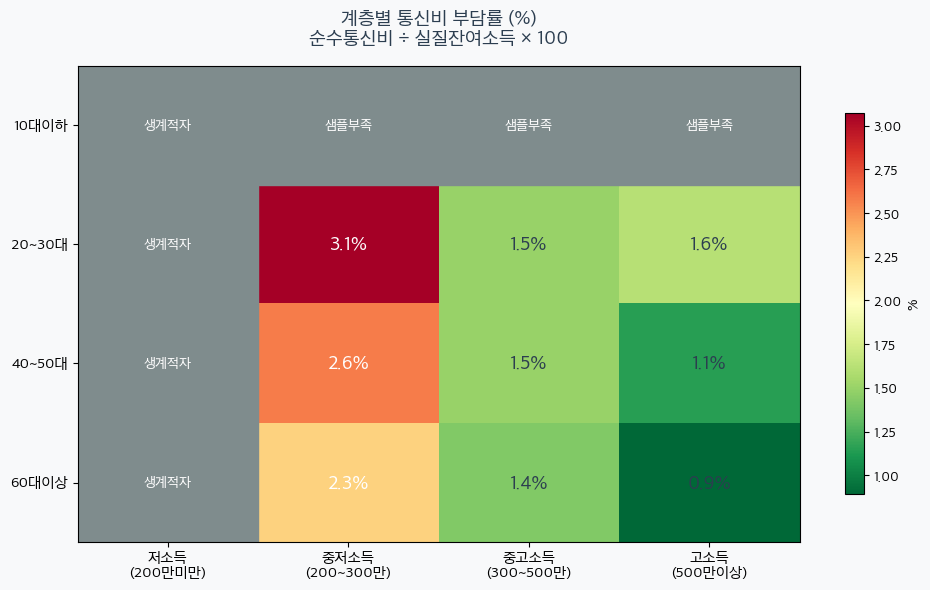

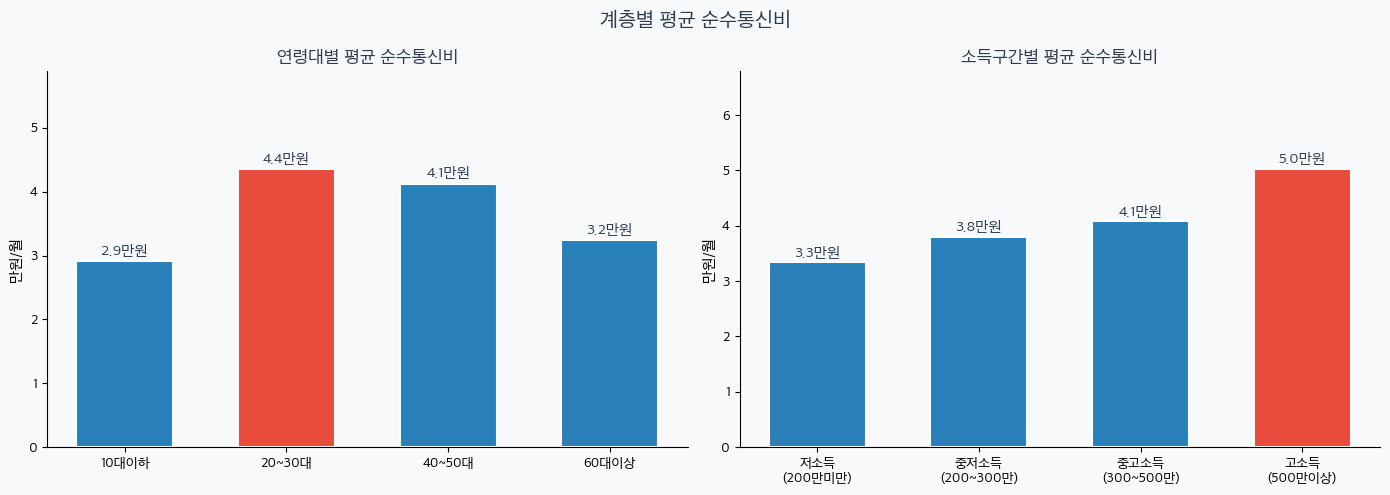

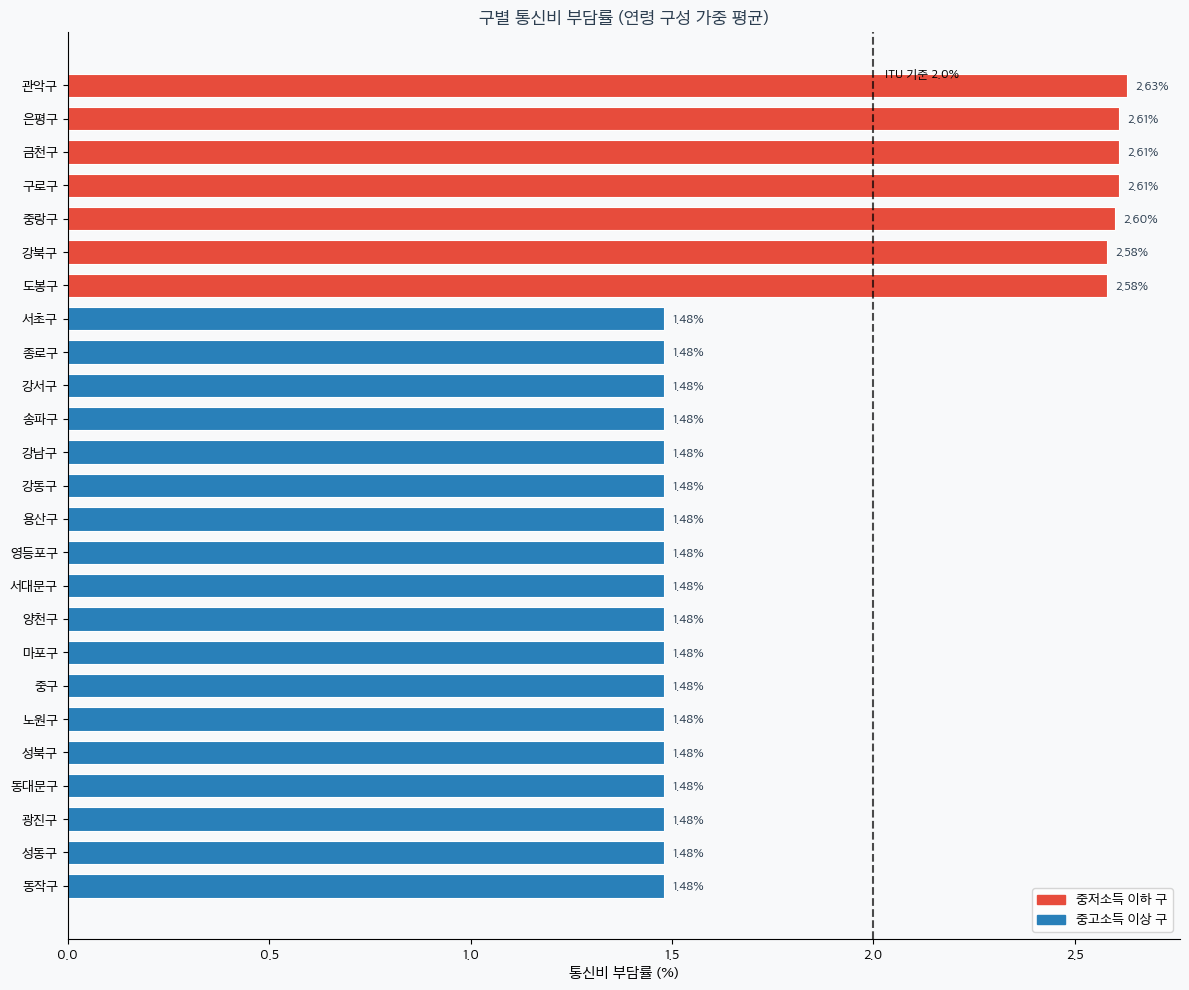

In [9]:
from src.visualization.plots import save_all

save_all(result, cleaned)


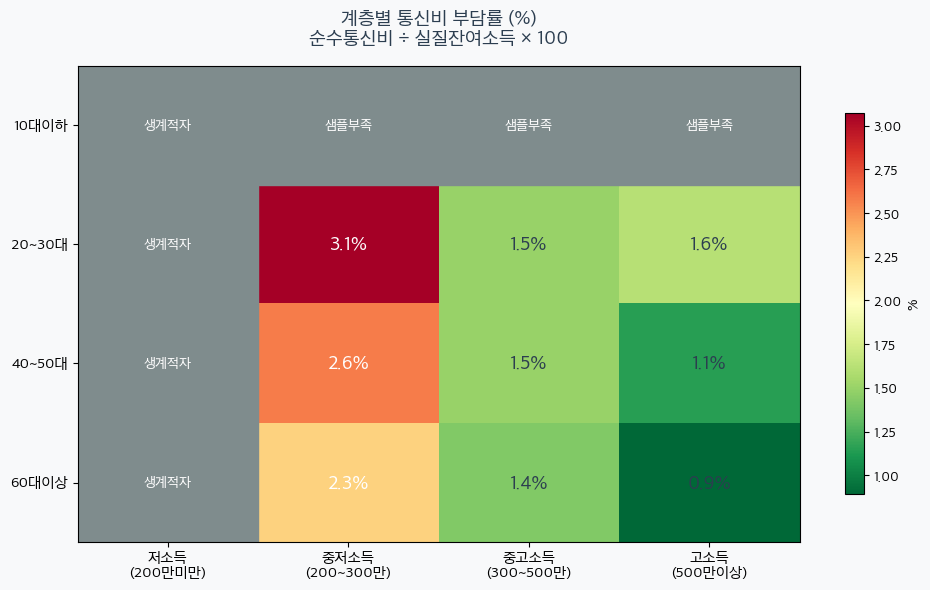

In [10]:
# 개별 차트 확인
from src.visualization.plots import (
    plot_burden_heatmap,
    plot_cost_by_group,
    plot_gu_burden,
)

plot_burden_heatmap(result["burden_matrix"])
plt.show()


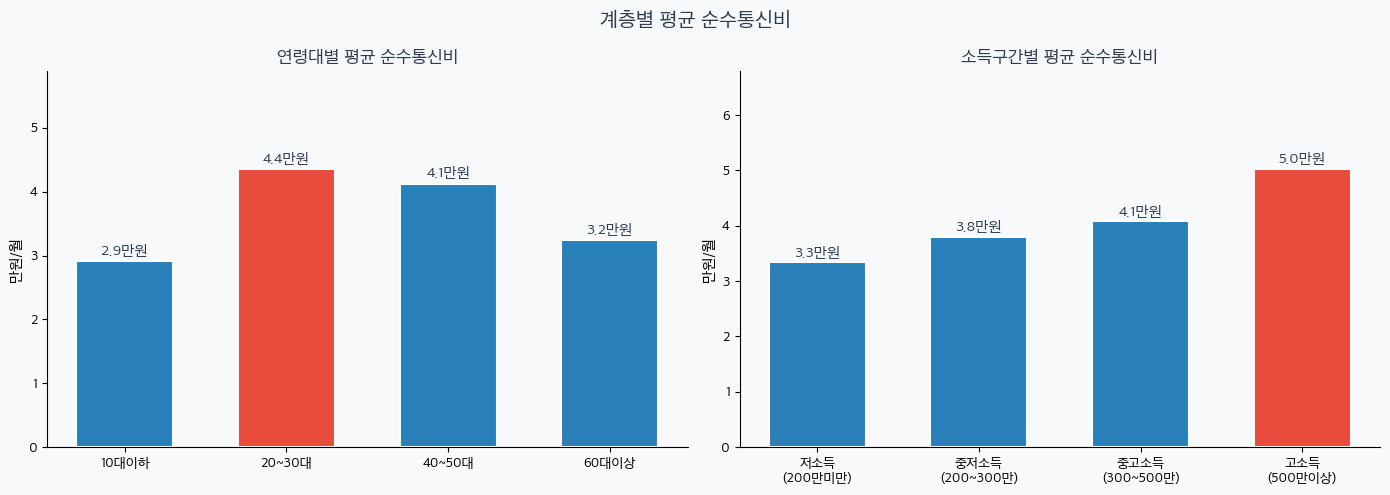

In [11]:
plot_cost_by_group(cleaned["seoul"])
plt.show()


/Users/jhhhyk/Documents/ITU Projects/itu_analize/ITU/src/visualization/plots.py:174: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(gu_s["구이름"], fontproperties=FP, fontsize=10)


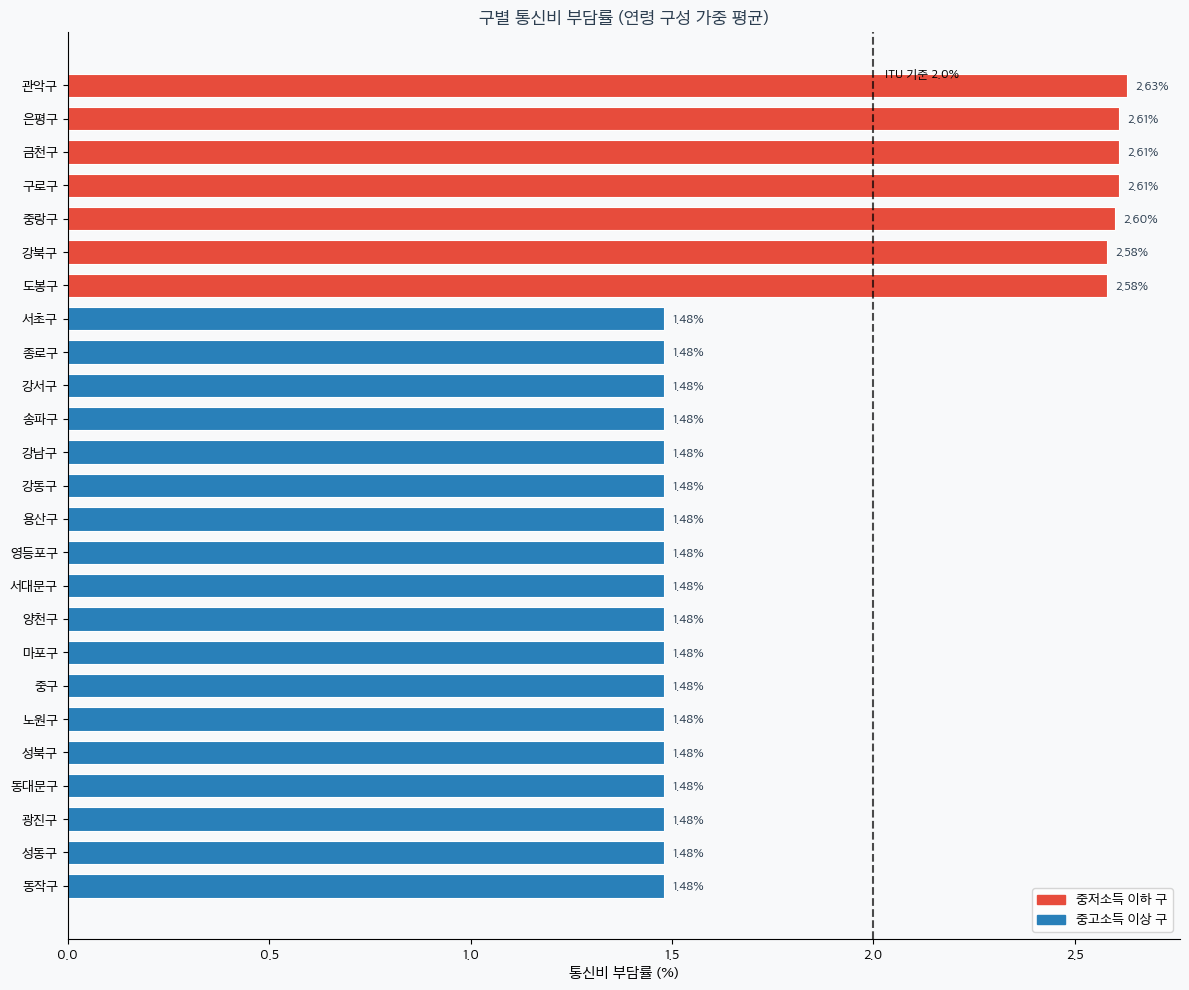

In [12]:
plot_gu_burden(result["gu_master"])
plt.show()


## 7. 주요 발견 (데이터 기반 귀납)

| 발견 | 내용 |
|------|------|
| 생계 적자 | 저소득(200만미만) 전 연령대 — 통신비 이전에 이미 적자 |
| 최고 부담 | **20~30대 × 중저소득** 3.11% → ITU 기준 2% 초과 |
| 예상 반박 | 60대이상 × 고소득 0.89% → 노인=취약 전제가 데이터로 반박됨 |
| ITU 초과 구 | 관악·구로·금천·은평·중랑·강북·도봉 (7개) |

> 분석 의사결정 기록 → 


In [13]:
# 결과 Excel 저장 (reports/)
from pathlib import Path
import yaml

with open("configs/config.yaml") as f:
    cfg = yaml.safe_load(f)

report_dir = Path(cfg["paths"]["outputs"]) / "reports"
report_dir.mkdir(parents=True, exist_ok=True)
out_path = report_dir / "03_affordability_result.xlsx"

with pd.ExcelWriter(out_path, engine="openpyxl") as w:
    result["burden_matrix"].to_excel(w, sheet_name="계층별_부담률")
    result["cross_cost"].round(2).to_excel(w, sheet_name="계층별_평균통신비")
    result["cross_n"].to_excel(w, sheet_name="계층별_샘플수")
    result["gu_master"].to_excel(w, sheet_name="구별_부담률순위", index=False)

print(f"저장 완료: {out_path}")


저장 완료: outputs/reports/03_affordability_result.xlsx
